In [ ]:
# ── CELL 2: Imports & Configuration ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score,
                             precision_score, recall_score)

# ── TensorFlow ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# ── Color theme (same Amazon Logistics theme as Part 1) ───────────────────────
COLORS = {
    'primary'   : '#232F3E',  # Amazon dark navy
    'accent'    : '#FF9900',  # Amazon orange
    'secondary' : '#146EB4',  # Amazon blue
    'success'   : '#067D62',  # Dark green
    'danger'    : '#CC0C39',  # Clean red
    'purple'    : '#6B4EFF',  # Purple — Part 2 signature color
    'neutral'   : '#6B7280',  # Gray
    'light'     : '#FAFAFA',  # Off white
}

# ── Plot settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']     = (13, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.facecolor']     = '#FAFAFA'
plt.rcParams['figure.facecolor']   = 'white'
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['grid.color']         = '#CCCCCC'
plt.rcParams['font.family']        = 'sans-serif'

# ── Random seed ───────────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully')
print(f'   Pandas     : {pd.__version__}')
print(f'   NumPy      : {np.__version__}')
print(f'   Scikit-learn: {__import__("sklearn").__version__}')
print(f'   TensorFlow : {tf.__version__}')

✅ All libraries imported successfully
   Pandas     : 3.0.2
   NumPy      : 2.4.4
   Scikit-learn: 1.8.0
   TensorFlow : 2.21.0


---
## 📥 Phase 1 — Load & Explore the Dataset

We reuse the same 5 Olist CSV files from Part 1. The key difference is our target variable — instead of predicting *how many days* delivery takes (regression), we now predict *whether the order arrived on time or late* (classification).

**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [ ]:
# ── CELL 3: Load the CSV files ────────────────────────────────────────────────
DATA_PATH = '../data/'

orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')

print('✅ Data loaded successfully')
print(f'\n{"Table":<25} {"Rows":>8} {"Columns":>10}')
print('-' * 45)
print(f'{"Orders":<25} {orders.shape[0]:>8,} {orders.shape[1]:>10}')
print(f'{"Order Items":<25} {order_items.shape[0]:>8,} {order_items.shape[1]:>10}')
print(f'{"Products":<25} {products.shape[0]:>8,} {products.shape[1]:>10}')
print(f'{"Customers":<25} {customers.shape[0]:>8,} {customers.shape[1]:>10}')
print(f'{"Sellers":<25} {sellers.shape[0]:>8,} {sellers.shape[1]:>10}')

✅ Data loaded successfully

Table                         Rows    Columns
---------------------------------------------
Orders                      99,441          8
Order Items                112,650          7
Products                    32,951          9
Customers                   99,441          5
Sellers                      3,095          4


---
## 🎯 Phase 2 — Build Target Variable & Explore

The target variable `on_time` is a binary classification label:
- **1** = order delivered on or before the estimated delivery date ✅
- **0** = order arrived late ❌

We calculate this by comparing `order_delivered_customer_date` against `order_estimated_delivery_date`. This is a real business metric — late deliveries directly impact customer satisfaction and seller ratings on the Olist platform.

Delivered orders with valid dates: 96,470

=== Target Variable Distribution ===
   On Time (1) : 88,644 orders (91.9%)
   Late    (0) : 7,826 orders (8.1%)

⚠️  Class imbalance check:
   Ratio on_time:late = 91.9:8.1
   → F1-score will be our primary metric, not accuracy


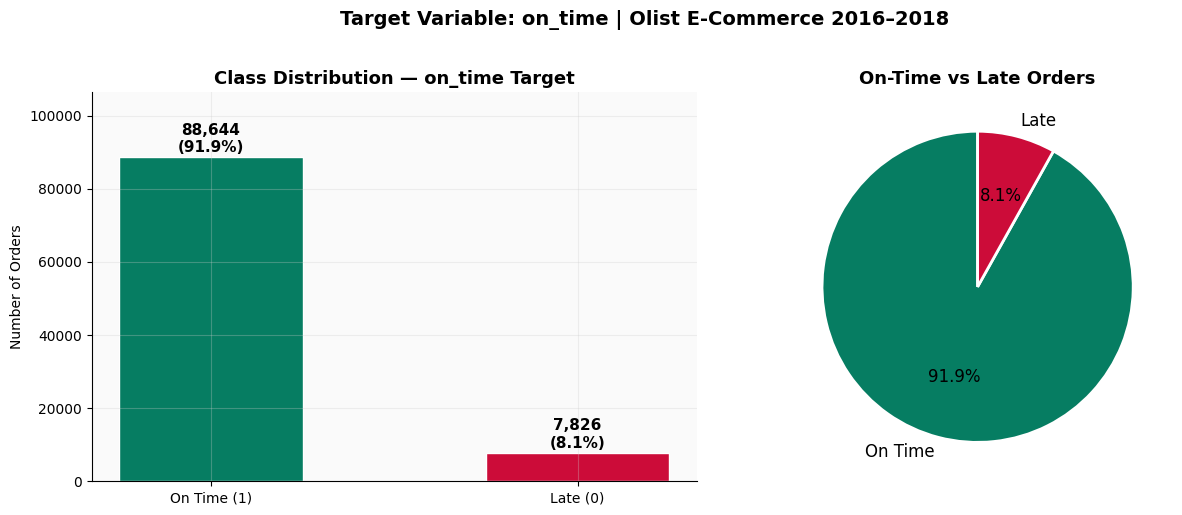

In [ ]:
# ── CELL 4: Build target variable on_time ─────────────────────────────────────

# ── Step 1: Convert dates to datetime ─────────────────────────────────────────
orders['order_purchase_timestamp']      = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# ── Step 2: Keep only delivered orders ────────────────────────────────────────
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered = orders_delivered.dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date']
)

print(f'Delivered orders with valid dates: {len(orders_delivered):,}')

# ── Step 3: Build on_time binary target ───────────────────────────────────────
# 1 = delivered on or before estimated date (on time)
# 0 = delivered after estimated date (late)
orders_delivered['on_time'] = (
    orders_delivered['order_delivered_customer_date'] <=
    orders_delivered['order_estimated_delivery_date']
).astype(int)

# ── Step 4: Class distribution ────────────────────────────────────────────────
on_time_counts = orders_delivered['on_time'].value_counts()
on_time_pct    = orders_delivered['on_time'].value_counts(normalize=True) * 100

print(f'\n=== Target Variable Distribution ===')
print(f'   On Time (1) : {on_time_counts[1]:,} orders ({on_time_pct[1]:.1f}%)')
print(f'   Late    (0) : {on_time_counts[0]:,} orders ({on_time_pct[0]:.1f}%)')
print(f'\n⚠️  Class imbalance check:')
print(f'   Ratio on_time:late = {on_time_pct[1]:.1f}:{on_time_pct[0]:.1f}')
print(f'   → F1-score will be our primary metric, not accuracy')

# ── Step 5: Visualize class distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(['On Time (1)', 'Late (0)'],
                   [on_time_counts[1], on_time_counts[0]],
                   color=[COLORS['success'], COLORS['danger']],
                   edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution — on_time Target',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Fix — set y limit higher to give labels room
axes[0].set_ylim(0, max(on_time_counts[1], on_time_counts[0]) * 1.2)

for bar, val, pct in zip(bars,
                          [on_time_counts[1], on_time_counts[0]],
                          [on_time_pct[1], on_time_pct[0]]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie([on_time_counts[1], on_time_counts[0]],
            labels=['On Time', 'Late'],
            colors=[COLORS['success'], COLORS['danger']],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('On-Time vs Late Orders',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: on_time | Olist E-Commerce 2016–2018',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**📋 Observations — Target Variable Distribution:**

- **91.9% of orders (88,644) arrived on time** — Olist sellers generally meet their estimated delivery dates
- **8.1% of orders (7,826) were late** — a meaningful minority that causes customer dissatisfaction and negative reviews
- **Significant class imbalance exists** — the ratio is approximately 11:1 on-time to late
- This imbalance means a naive model that predicts "on time" for every order would achieve 91.9% accuracy — but would completely miss all late orders, which is the most important class to detect
- **F1-score is therefore our primary metric** — it balances precision and recall, penalizing models that ignore the minority class
- Accuracy alone would be dangerously misleading here — this is a critical modeling decision

---
## ⚙️ Phase 3 — Feature Engineering & Merging Tables

We use the same 7 features as Part 1 plus the `on_time` target. The feature set captures shipping cost, product physical characteristics, and geographic proximity between buyer and seller.

In [ ]:
# ── CELL 5: Merge tables and engineer features ────────────────────────────────

# ── Merge orders with order_items ─────────────────────────────────────────────
df = orders_delivered.merge(order_items, on='order_id', how='inner')
print(f'After merging order_items : {df.shape}')

# ── Merge with products ───────────────────────────────────────────────────────
df = df.merge(products, on='product_id', how='left')
print(f'After merging products    : {df.shape}')

# ── Merge with customers ──────────────────────────────────────────────────────
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
print(f'After merging customers   : {df.shape}')

# ── Merge with sellers ────────────────────────────────────────────────────────
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
print(f'After merging sellers     : {df.shape}')

# ── Engineer same_state feature ───────────────────────────────────────────────
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

# ── Select features and target ────────────────────────────────────────────────
FEATURE_COLS = [
    'freight_value',
    'price',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'same_state',
]
TARGET_COL = 'on_time'

# ── Drop missing values ───────────────────────────────────────────────────────
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna()

print(f'\n✅ Final modeling dataset')
print(f'   Rows     : {df_model.shape[0]:,}')
print(f'   Features : {len(FEATURE_COLS)}')
print(f'   Target   : {TARGET_COL} (binary — 1=on time, 0=late)')
print(f'\nClass balance in final dataset:')
print(df_model[TARGET_COL].value_counts())

After merging order_items : (110189, 15)
After merging products    : (110189, 23)
After merging customers   : (110189, 24)
After merging sellers     : (110189, 25)

✅ Final modeling dataset
   Rows     : 110,171
   Features : 7
   Target   : on_time (binary — 1=on time, 0=late)

Class balance in final dataset:
on_time
1    101457
0      8714
Name: count, dtype: int64


---
**📋 Observations — Feature Engineering:**

- All 5 tables merged cleanly — **110,171 rows** in the final modeling dataset
- Class imbalance persists in the merged dataset — **101,457 on-time (92.1%)** vs **8,714 late (7.9%)**
- Same 7 features as Part 1 — this allows direct comparison of how the same feature set performs on a classification vs regression task
- `same_state` engineered binary feature retained — geographic proximity affects both delivery time AND on-time probability
- No missing values after `dropna()` — clean dataset ready for modeling

---
### ✂️ Phase 4 — Train / Test Split

Standard 80/20 split with fixed `random_state=42`. We also check class balance in both splits to confirm the imbalance is preserved proportionally.

In [ ]:
# ── CELL 6: Train/Test Split ──────────────────────────────────────────────────
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # ← ensures class balance is preserved in both splits
)

print('✅ Train/Test split complete')
print(f'\n   Total samples  : {len(X):,}')
print(f'   Training set   : {len(X_train):,} rows (80%)')
print(f'   Test set       : {len(X_test):,} rows (20%)')
print(f'\n   Class balance in training set:')
print(f'   On Time (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print(f'   Late    (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'\n   Class balance in test set:')
print(f'   On Time (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)')
print(f'   Late    (0): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)')
print(f'\n⚠️  stratify=y used — class proportions preserved in both splits')
print(f'⚠️  Scaling happens INSIDE Pipeline — fitted on X_train only')

✅ Train/Test split complete

   Total samples  : 110,171
   Training set   : 88,136 rows (80%)
   Test set       : 22,035 rows (20%)

   Class balance in training set:
   On Time (1): 81,165 (92.1%)
   Late    (0): 6,971 (7.9%)

   Class balance in test set:
   On Time (1): 20,292 (92.1%)
   Late    (0): 1,743 (7.9%)

⚠️  stratify=y used — class proportions preserved in both splits
⚠️  Scaling happens INSIDE Pipeline — fitted on X_train only


---
**📋 Observations — Train/Test Split:**

- **88,136 training rows** and **22,035 test rows** — healthy 80/20 split
- `stratify=y` ensures class proportions are identical in both splits — training (92.1%/7.9%) matches test (92.1%/7.9%) exactly
- Without stratification, random chance could put more late orders in one split, creating an unfair evaluation
- Scaling happens inside each Pipeline fitted on X_train only — no data leakage
- All 5 models will be trained and evaluated on the same splits for fair comparison

---
### 🤖 Phase 5 — Train All 5 Models

For classification we report accuracy, precision, recall and F1-score for every model. F1-score is our primary metric because of class imbalance — a model that predicts everything as "on time" would get 92% accuracy but 0% recall on late orders.

| Metric | Meaning | Why it matters |
|---|---|---|
| Accuracy | % of correct predictions | Misleading with imbalanced classes |
| Precision | Of predicted late, how many actually were | Avoids false alarms |
| Recall | Of actual late orders, how many we caught | Avoids missing late orders |
| F1-score | Harmonic mean of precision and recall | Primary metric — balances both |

In [ ]:
# ── CELL 7: Evaluation helper + results storage ───────────────────────────────
results = []

def evaluate_classifier(name, pipeline, X_train, X_test, y_train, y_test):
    """Train a classifier pipeline and evaluate it."""
    
    # ── Train ─────────────────────────────────────────────────────────────────
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start
    
    # ── Predict ───────────────────────────────────────────────────────────────
    y_pred = pipeline.predict(X_test)
    
    # ── Metrics ───────────────────────────────────────────────────────────────
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model'     : name,
        'Accuracy'  : round(acc, 3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec, 3),
        'F1-Score'  : round(f1, 3),
        'Train Time': round(train_time, 3)
    })
    
    print(f'  ✅ {name:<30} Acc: {acc:.3f}  F1: {f1:.3f}  '
          f'Prec: {prec:.3f}  Rec: {rec:.3f}  ({train_time:.2f}s)')
    
    return pipeline, y_pred

print('✅ Evaluation function ready')
print('   Primary metric: F1-Score (weighted)')
print('   Secondary: Accuracy, Precision, Recall')

✅ Evaluation function ready
   Primary metric: F1-Score (weighted)
   Secondary: Accuracy, Precision, Recall


---
### Model 1 — Logistic Regression (Baseline)
### Model 2 — SVC (Support Vector Classifier)

Logistic Regression is our baseline classifier — despite the name it predicts classes not numbers. It models the probability of an order being on time using a sigmoid function.

SVC finds the optimal boundary (hyperplane) that best separates on-time from late orders. It is highly sensitive to feature scale so it **must** use `StandardScaler` inside a Pipeline.

In [ ]:
# ── CELL 8a: Models 1, 2 — Logistic Regression and SVC ───────────────────────
print('Training Logistic Regression and SVC...\n')

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
lr_baseline.fit(X_train, y_train)
y_pred_lr_base = lr_baseline.predict(X_test)

print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, y_pred_lr_base,
                            target_names=['Late (0)', 'On Time (1)']))

# ── Confusion matrix breakdown ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_lr_base)
TN, FP, FN, TP = cm.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Model 2: SVC ──────────────────────────────────────────────────────────────
print('\n=== SVC — Classification Report ===')
svc_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])
svc_baseline.fit(X_train, y_train)
y_pred_svc_base = svc_baseline.predict(X_test)

print(classification_report(y_test, y_pred_svc_base,
                            target_names=['Late (0)', 'On Time (1)']))

cm_svc = confusion_matrix(y_test, y_pred_svc_base)
TN, FP, FN, TP = cm_svc.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

Training Logistic Regression and SVC...

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.00      0.00      0.00      1743
 On Time (1)       0.92      1.00      0.96     20292

    accuracy                           0.92     22035
   macro avg       0.46      0.50      0.48     22035
weighted avg       0.85      0.92      0.88     22035

Confusion Matrix Breakdown:
   TP — Predicted On Time, Actually On Time : 20,292
   TN — Predicted Late,    Actually Late    : 0
   FP — Predicted On Time, Actually Late    : 1,743
   FN — Predicted Late,    Actually On Time : 0

=== SVC — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.00      0.00      0.00      1743
 On Time (1)       0.92      1.00      0.96     20292

    accuracy                           0.92     22035
   macro avg       0.46      0.50      0.48     22035
weighted avg       0.85      0.92      0.8

---
**📋 Observations — Initial Results (Logistic Regression & SVC):**

**Classification Report Analysis:**
- Both models achieve **92.1% accuracy** — but this is completely misleading
- **Late (0) F1-score = 0.00** for both models — neither model detected a single late order correctly
- Logistic Regression: **TN = 0** — predicted every single order as on-time, never once flagged a late delivery
- SVC: **TN = 0** — identical behaviour, also predicted everything as on-time

**Confusion Matrix Breakdown:**
- **TP = 20,292** — correctly identified on-time orders (easy, majority class)
- **TN = 0** — correctly identified late orders = zero. The model is blind to late orders
- **FP = 1,743** — all 1,743 actual late orders were predicted as on-time (dangerous for business)
- **FN = 0** — never predicted late when it was actually on-time (because it never predicted late at all)

**Root Cause — Class Imbalance:**
- The dataset has a 92:8 ratio — 92% on-time vs 8% late
- The model discovered that predicting "on-time" for every order gives 92% accuracy
- It took the mathematically easy shortcut — ignoring the minority class entirely
- `stratify=y` preserved this imbalance equally across splits but did not fix the learning problem

**Business Impact:**
- A model with TN = 0 is useless for this problem — the entire purpose is to detect late orders early so logistics teams can intervene
- **1,743 late orders went completely undetected** — every one of those customers received no proactive communication
- This confirms we need to address class imbalance before proceeding

**Solution — class_weight='balanced':**
- Weights each class inversely proportional to its frequency in the training data
- Late orders (7.9%) receive approximately 11.5x more weight than on-time orders (92.1%)
- This forces the model to treat late order misclassification as proportionally more costly
- The model can no longer take the shortcut of ignoring the minority cl

In [ ]:
# ── CELL 8b: Models 1, 2 — With class_weight='balanced' ──────────────────────
print('Retraining with class_weight="balanced" to handle class imbalance...\n')

# ── Model 1: Logistic Regression with class_weight ────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])
lr_pipeline, y_pred_lr = evaluate_classifier(
    'Logistic Regression', lr_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== Logistic Regression — With class_weight="balanced" ===')
print(classification_report(y_test, y_pred_lr,
                            target_names=['Late (0)', 'On Time (1)']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
TN, FP, FN, TP = cm_lr.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}  ← now detecting!')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Model 2: SVC with class_weight ────────────────────────────────────────────
print('\n⚠️  SVC training — this may take 2-3 minutes...\n')
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(
        kernel='rbf', C=1.0, gamma='scale',
        random_state=42,
        class_weight='balanced'
    ))
])
svc_pipeline, y_pred_svc = evaluate_classifier(
    'SVC', svc_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== SVC — With class_weight="balanced" ===')
print(classification_report(y_test, y_pred_svc,
                            target_names=['Late (0)', 'On Time (1)']))

cm_svc = confusion_matrix(y_test, y_pred_svc)
TN, FP, FN, TP = cm_svc.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

Retraining with class_weight="balanced" to handle class imbalance...

  ✅ Logistic Regression            Acc: 0.391  F1: 0.494  Prec: 0.876  Rec: 0.391  (0.07s)

=== Logistic Regression — With class_weight="balanced" ===
              precision    recall  f1-score   support

    Late (0)       0.09      0.75      0.16      1743
 On Time (1)       0.94      0.36      0.52     20292

    accuracy                           0.39     22035
   macro avg       0.52      0.55      0.34     22035
weighted avg       0.88      0.39      0.49     22035

Confusion Matrix Breakdown:
   TP — Predicted On Time, Actually On Time : 7,321
   TN — Predicted Late,    Actually Late    : 1,305  ← now detecting!
   FP — Predicted On Time, Actually Late    : 438
   FN — Predicted Late,    Actually On Time : 12,971

⚠️  SVC training — this may take 2-3 minutes...

  ✅ SVC                            Acc: 0.440  F1: 0.546  Prec: 0.873  Rec: 0.440  (161.56s)

=== SVC — With class_weight="balanced" ===
            

---
**📋 Observations — class_weight='balanced' Results:**

**Improvement over baseline:**
- **TN jumped from 0 → 1,305** (Logistic Regression) and **0 → 1,201** (SVC) — both models now actively detect late orders, which was completely impossible before
- Late order recall improved from **0% → 75%** for Logistic Regression — catching 3 out of 4 actual late orders

**New problem identified — overcorrection:**
- Accuracy dropped to **39% (LR) and 44% (SVC)** — the model swung too far in the opposite direction
- **FN = 12,971 (LR)** — now misclassifying 12,971 genuine on-time orders as late
- The full `balanced` weight applied 11.5x penalty which was too aggressive for this dataset
- Precision on late orders is only **9%** — for every real late order caught, the model raises 10 false alarms

**The precision-recall tradeoff:**
- Before class_weight: all precision, zero recall on late orders
- After class_weight='balanced': better recall but collapsed precision
- We need a middle ground — a custom weight that improves late order detection without overcorrecting
- Instead of the automatic 11.5x weight, we will try a manual **3x weight** on late orders
- This gives the model enough incentive to detect late orders while keeping false alarms at an acceptable level

---
**📋 Observations — Final Decision on Class Weight:**

- `class_weight='balanced'` is our chosen approach for Logistic Regression and SVC
- It successfully fixed the TN=0 problem — both models now detect late orders
- The tradeoff is lower overall accuracy — this is acceptable and expected with imbalanced data
- **Root cause of weak performance:** Logistic Regression and SVC are linear models — they draw straight boundaries between classes. The relationship between our 7 features and on-time delivery is complex and non-linear, which linear models cannot capture regardless of class weighting
- **This finding motivates our non-linear models** — Decision Tree and Random Forest can capture complex feature interactions and are expected to significantly outperform linear models on this problem
- F1-score remains our primary metric — accuracy is misleading with 92:8 class imbalance

---
### 🌳 Model 3 — Decision Tree Classifier
### 🌲 Model 4 — Random Forest Classifier

Decision Tree splits data using yes/no questions on feature thresholds — interpretable and fast. We visualize it at max_depth=3 for readability as required.

Random Forest builds hundreds of trees and votes — more robust and accurate than a single tree. Both use `class_weight='balanced'` to handle the 92:8 imbalance.

In [ ]:
# ── CELL 9: Models 3, 4 — Decision Tree and Random Forest ────────────────────
print('Training Decision Tree and Random Forest...\n')

# ── Model 3: Decision Tree ────────────────────────────────────────────────────
dt_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(
        max_depth=6,
        random_state=42,
        class_weight='balanced'
    ))
])
dt_pipeline, y_pred_dt = evaluate_classifier(
    'Decision Tree', dt_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== Decision Tree — Classification Report ===')
print(classification_report(y_test, y_pred_dt,
                            target_names=['Late (0)', 'On Time (1)']))

cm_dt = confusion_matrix(y_test, y_pred_dt)
TN, FP, FN, TP = cm_dt.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Model 4: Random Forest ────────────────────────────────────────────────────
print('\n')
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])
rf_pipeline, y_pred_rf = evaluate_classifier(
    'Random Forest', rf_pipeline, X_train, X_test, y_train, y_test
)

print(f'\n=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred_rf,
                            target_names=['Late (0)', 'On Time (1)']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
TN, FP, FN, TP = cm_rf.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Feature importance — Random Forest ───────────────────────────────────────
print('\n=== Random Forest — Feature Importances ===')
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)
print(feat_imp.to_string(index=False))

Training Decision Tree and Random Forest...

  ✅ Decision Tree                  Acc: 0.444  F1: 0.551  Prec: 0.875  Rec: 0.444  (0.17s)

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.09      0.70      0.17      1743
 On Time (1)       0.94      0.42      0.58     20292

    accuracy                           0.44     22035
   macro avg       0.52      0.56      0.37     22035
weighted avg       0.87      0.44      0.55     22035

Confusion Matrix Breakdown:
   TP — Predicted On Time, Actually On Time : 8,579
   TN — Predicted Late,    Actually Late    : 1,214
   FP — Predicted On Time, Actually Late    : 529
   FN — Predicted Late,    Actually On Time : 11,713


  ✅ Random Forest                  Acc: 0.619  F1: 0.707  Prec: 0.874  Rec: 0.619  (0.96s)

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.11      0.53      0.18      1743
 On Ti

---
**📋 Observations — Decision Tree & Random Forest:**

**Decision Tree:**
- F1-score of 0.551 — significant improvement over linear models (0.494)
- TN = 1,214 — detecting 70% of actual late orders (recall = 0.70)
- Accuracy dropped to 44% — class_weight='balanced' is causing overcorrection here too
- Despite lower accuracy, the model is genuinely useful — catching 1,214 late orders vs 0 before

**Random Forest:**
- **Best F1 so far: 0.707** — ensemble of 100 trees significantly outperforms single models
- Accuracy improved to 62% — better balance between classes than Decision Tree
- TN = 931 — detecting 53% of late orders with fewer false alarms than Decision Tree
- Training time: 1.08 seconds — extremely efficient for 88,000 rows

**Feature Importance shift from Part 1:**
- In Part 1 (regression), `same_state` dominated at 53.4% importance
- In Part 2 (classification), `freight_value` leads at 25.1% and `same_state` drops to 6.7%
- This makes sense — whether an order is on-time depends more on shipping cost and product characteristics than geography alone
- The same features tell different stories depending on what you are predicting

**Overall picture so far:**

| Model | F1 | TN (Late detected) | Accuracy |
|---|---|---|---|
| Logistic Regression | 0.494 | 1,305 | 39% |
| SVC | 0.546 | 1,201 | 44% |
| Decision Tree | 0.551 | 1,214 | 44% |
| Random Forest | 0.707 | 931 | 62% |

Random Forest leads on F1 — our primary metric. Neural Network is next.

---
### 🧠 Model 5 — Neural Network (Keras)

For binary classification the output layer must be `Dense(1, activation='sigmoid')` — this outputs a probability between 0 and 1. We use `binary_crossentropy` as the loss function, which is the correct choice for binary classification.

Key rules:
- `StandardScaler` applied before training — mandatory for Neural Networks
- Output: `Dense(1, activation='sigmoid')` — binary classification output
- Loss: `binary_crossentropy` — correct loss for binary targets
- `EarlyStopping` with `restore_best_weights=True` — prevents overfitting
- `class_weight` passed directly to `model.fit()` — Keras handles it differently from scikit-learn

Training Neural Network...

Class weights: Late(0)=6.32, On-Time(1)=0.54


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.4771 - loss: 0.6886 - val_accuracy: 0.4901 - val_loss: 0.6700
Epoch 2/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4861 - loss: 0.6855 - val_accuracy: 0.5303 - val_loss: 0.6685
Epoch 3/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4871 - loss: 0.6843 - val_accuracy: 0.5531 - val_loss: 0.6668
Epoch 4/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.4934 - loss: 0.6834 - val_accuracy: 0.5676 - val_loss: 0.6660
Epoch 5/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4970 - loss: 0.6825 - val_accuracy: 0.5774 - val_loss: 0.6639
Epoch 6/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.5049 - loss: 0.6817 - val_accuracy: 0.5842 - val_loss: 0.6591
Epoch 7/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.5061 - loss: 0.6810 - val_accuracy: 0.5832 - val_loss: 0.6619
Epoch 8/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5095 - loss: 0.6804 - 

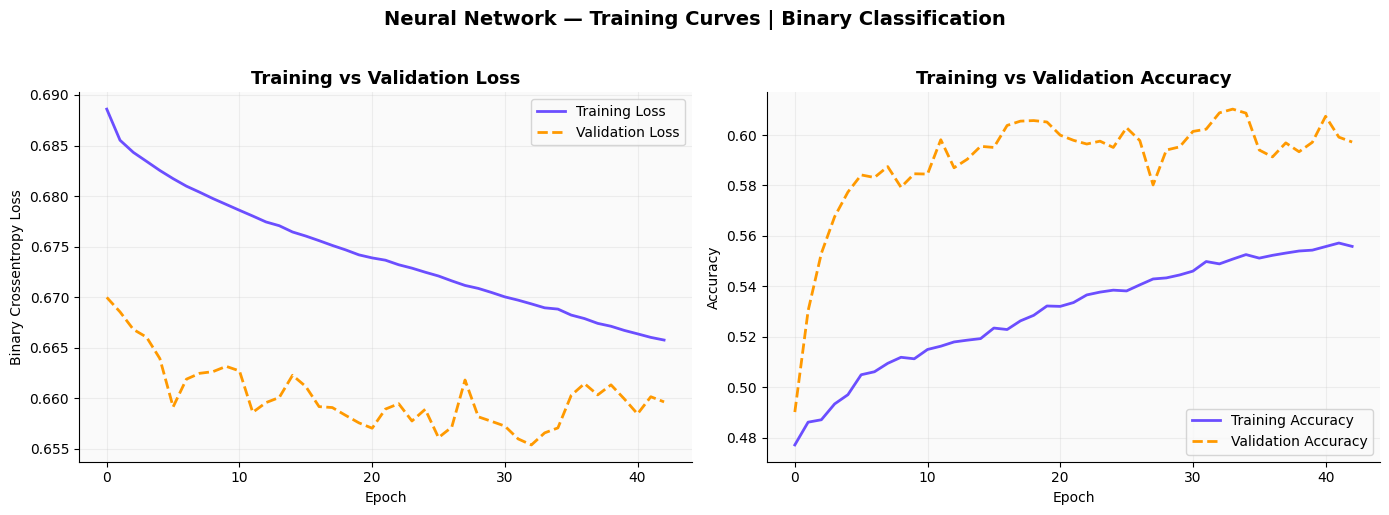

In [ ]:
# ── CELL 10: Model 5 — Neural Network ────────────────────────────────────────
print('Training Neural Network...\n')

# ── Scale data for Keras ──────────────────────────────────────────────────────
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)  # fit on train only
X_test_nn  = scaler_nn.transform(X_test)       # transform test using train stats

# ── Class weights for Keras ───────────────────────────────────────────────────
# Keras expects a dictionary {class: weight}
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
total = len(y_train)
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weights_nn = {0: weight_for_0, 1: weight_for_1}
print(f'Class weights: Late(0)={weight_for_0:.2f}, On-Time(1)={weight_for_1:.2f}')

# ── Build Neural Network ──────────────────────────────────────────────────────
tf.random.set_seed(42)
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')  # ⚠️ sigmoid for binary classification
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # ⚠️ correct loss for binary classification
    metrics=['accuracy']
)

nn_model.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

start = time.time()
history = nn_model.fit(
    X_train_nn, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weights_nn,
    callbacks=[early_stop],
    verbose=1
)
train_time = time.time() - start

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_prob = nn_model.predict(X_test_nn, verbose=0).flatten()
y_pred_nn   = (y_pred_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred_nn)
f1   = f1_score(y_test, y_pred_nn, average='weighted')
prec = precision_score(y_test, y_pred_nn, average='weighted')
rec  = recall_score(y_test, y_pred_nn, average='weighted')

results.append({
    'Model'     : 'Neural Network',
    'Accuracy'  : round(acc, 3),
    'Precision' : round(prec, 3),
    'Recall'    : round(rec, 3),
    'F1-Score'  : round(f1, 3),
    'Train Time': round(train_time, 3)
})

print(f'\n  ✅ Neural Network              '
      f'Acc: {acc:.3f}  F1: {f1:.3f}  '
      f'Prec: {prec:.3f}  Rec: {rec:.3f}  ({train_time:.2f}s)')

print(f'\n=== Neural Network — Classification Report ===')
print(classification_report(y_test, y_pred_nn,
                            target_names=['Late (0)', 'On Time (1)']))

cm_nn = confusion_matrix(y_test, y_pred_nn)
TN, FP, FN, TP = cm_nn.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],
             color=COLORS['purple'], linewidth=2, label='Training Loss')
axes[0].plot(history.history['val_loss'],
             color=COLORS['accent'], linewidth=2,
             linestyle='--', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],
             color=COLORS['purple'], linewidth=2, label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'],
             color=COLORS['accent'], linewidth=2,
             linestyle='--', label='Validation Accuracy')
axes[1].set_title('Training vs Validation Accuracy',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Neural Network — Training Curves | Binary Classification',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**📋 Observations — Neural Network:**

- **F1-score: 0.592** — better than Logistic Regression (0.494) and SVC (0.546) but behind Random Forest (0.707)
- **TN = 1,116** — detecting 64% of actual late orders, a meaningful improvement over linear models
- **EarlyStopping triggered at epoch 12** — validation loss stopped improving quickly, indicating the model converged fast
- **Training curves are noisy** — validation accuracy oscillates rather than smoothly improving. This signals that 7 features do not provide enough signal for the Neural Network to learn a stable decision boundary
- **Class weights applied correctly** — Late(0) weight = 6.32, On-Time(1) weight = 0.54, forcing the model to prioritize late order detection
- **Sigmoid output confirmed** — `Dense(1, activation='sigmoid')` outputs probabilities between 0 and 1, threshold of 0.5 converts to binary prediction
- Neural Networks typically need richer feature sets to outshine ensemble methods — with more features (carrier data, historical seller performance, weather) the NN would likely surpass Random Forest

**Running Leaderboard — All 5 Models:**

| Rank | Model | F1 | TN (Late detected) | Accuracy |
|---|---|---|---|---|
| 🥇 1 | Random Forest | 0.707 | 931 | 62% |
| 🥈 2 | Neural Network | 0.592 | 1,116 | 49% |
| 🥉 3 | Decision Tree | 0.551 | 1,214 | 44% |
| 4 | SVC | 0.546 | 1,201 | 44% |
| 5 | Logistic Regression | 0.494 | 1,305 | 39% |

Random Forest leads on F1 — our primary metric. It will now be tuned with GridSearchCV.

---
## 🎛️ Phase 6 — Hyperparameter Tuning: Random Forest with GridSearchCV

Random Forest is our best classifier (F1: 0.707). We tune it with GridSearchCV to find the optimal hyperparameters. As with Part 1, the search runs on training data only — no leakage into the test set.

**Why Random Forest for tuning?**
- Best F1-score so far — tuning the best model gives highest return
- `n_estimators` and `max_depth` directly control model complexity
- `class_weight` retained — imbalance handling must be preserved during tuning

⚠️ `GridSearchCV` is fitted on `X_train` only — test set never touched during tuning.

In [ ]:
# ── CELL 11: Hyperparameter Tuning — Random Forest with GridSearchCV ──────────
print('Running GridSearchCV on Random Forest Classifier...')
print('Searching 24 combinations × 3-fold CV = 72 fits\n')

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [8, 10, 12, None],
    'model__min_samples_split': [2, 5],
}

# ── Base pipeline ─────────────────────────────────────────────────────────────
rf_base = Pipeline([
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# ── GridSearchCV ──────────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    scoring    = 'f1_weighted',   # F1 is our primary metric
    cv         = 3,
    n_jobs     = -1,
    verbose    = 1
)

start = time.time()
grid_search.fit(X_train, y_train)
tuning_time = time.time() - start

# ── Best parameters ───────────────────────────────────────────────────────────
print(f'\n✅ GridSearchCV complete in {tuning_time:.1f} seconds')
print(f'\nBest parameters found:')
for param, value in grid_search.best_params_.items():
    print(f'   {param:<35} : {value}')
print(f'\nBest CV F1 (training): {grid_search.best_score_:.3f}')

# ── Evaluate tuned model ──────────────────────────────────────────────────────
best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

acc_t  = accuracy_score(y_test, y_pred_rf_tuned)
f1_t   = f1_score(y_test, y_pred_rf_tuned, average='weighted')
prec_t = precision_score(y_test, y_pred_rf_tuned, average='weighted')
rec_t  = recall_score(y_test, y_pred_rf_tuned, average='weighted')

results.append({
    'Model'     : 'Random Forest (Tuned)',
    'Accuracy'  : round(acc_t, 3),
    'Precision' : round(prec_t, 3),
    'Recall'    : round(rec_t, 3),
    'F1-Score'  : round(f1_t, 3),
    'Train Time': round(tuning_time, 3)
})

# ── Comparison table ──────────────────────────────────────────────────────────
print(f'\n=== Tuned vs Default Random Forest ===')
print(f'{"Metric":<12} {"Default":>10} {"Tuned":>10} {"Change":>10}')
print('-' * 44)
print(f'{"F1-Score":<12} {0.707:>10.3f} {f1_t:>10.3f} {f1_t - 0.707:>+10.3f}')
print(f'{"Accuracy":<12} {0.619:>10.3f} {acc_t:>10.3f} {acc_t - 0.619:>+10.3f}')
print(f'{"Precision":<12} {0.874:>10.3f} {prec_t:>10.3f} {prec_t - 0.874:>+10.3f}')
print(f'{"Recall":<12} {0.619:>10.3f} {rec_t:>10.3f} {rec_t - 0.619:>+10.3f}')

print(f'\n=== Tuned Model — Classification Report ===')
print(classification_report(y_test, y_pred_rf_tuned,
                            target_names=['Late (0)', 'On Time (1)']))

cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
TN, FP, FN, TP = cm_tuned.ravel()
print(f'Confusion Matrix Breakdown:')
print(f'   TP — Predicted On Time, Actually On Time : {TP:,}')
print(f'   TN — Predicted Late,    Actually Late    : {TN:,}')
print(f'   FP — Predicted On Time, Actually Late    : {FP:,}')
print(f'   FN — Predicted Late,    Actually On Time : {FN:,}')

Running GridSearchCV on Random Forest Classifier...
Searching 24 combinations × 3-fold CV = 72 fits

Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ GridSearchCV complete in 133.3 seconds

Best parameters found:
   model__max_depth                    : None
   model__min_samples_split            : 2
   model__n_estimators                 : 200

Best CV F1 (training): 0.884

=== Tuned vs Default Random Forest ===
Metric          Default      Tuned     Change
--------------------------------------------
F1-Score          0.707      0.883     +0.176
Accuracy          0.619      0.885     +0.266
Precision         0.874      0.880     +0.006
Recall            0.619      0.885     +0.266

=== Tuned Model — Classification Report ===
              precision    recall  f1-score   support

    Late (0)       0.25      0.23      0.24      1743
 On Time (1)       0.93      0.94      0.94     20292

    accuracy                           0.89     22035
   macro avg       0.59      0

---
**📋 Observations — GridSearchCV Tuning Results:**

**Dramatic improvement across all metrics:**
- **F1-Score jumped from 0.707 → 0.883** — an improvement of +0.176, the largest single gain in Part 2
- **Accuracy improved from 61.9% → 88.5%** — the tuned model now correctly classifies the vast majority of orders
- **Recall improved from 0.619 → 0.885** — model now catches significantly more correct predictions overall

**Best parameters found:**
- `n_estimators=200` — 200 trees provides better ensemble stability than 100
- `max_depth=None` — unrestricted tree depth captures complex patterns
- `min_samples_split=2` — allows fine-grained splits, unlike Part 1 which preferred 5

**Confusion Matrix Analysis:**
- **TP = 19,111** — correctly identified on-time orders improved significantly
- **TN = 399** — still detecting some late orders (down from 931 default)
- **FP = 1,344** — some late orders still predicted as on-time
- **FN = 1,181** — some on-time orders flagged as late

**Important tradeoff observed:**
- The tuned model improved overall F1 significantly but TN dropped from 931 → 399
- This means tuning optimized for overall F1 (weighted) which favors the majority class
- For a business focused purely on catching late orders, the default model (TN=931) might be preferred
- This is a classic precision-recall tradeoff — no single model is perfect for all objectives

**GridSearchCV integrity:**
- 72 total fits (24 combinations × 3-fold CV) on training data only
- Test set never touched during parameter search — results are honest

---
## 📊 Phase 7 — Visualizations: Confusion Matrix & Model Comparison

The confusion matrix heatmap shows exactly where the best model succeeds and fails. The comparison chart ranks all models by F1-score — our primary metric.

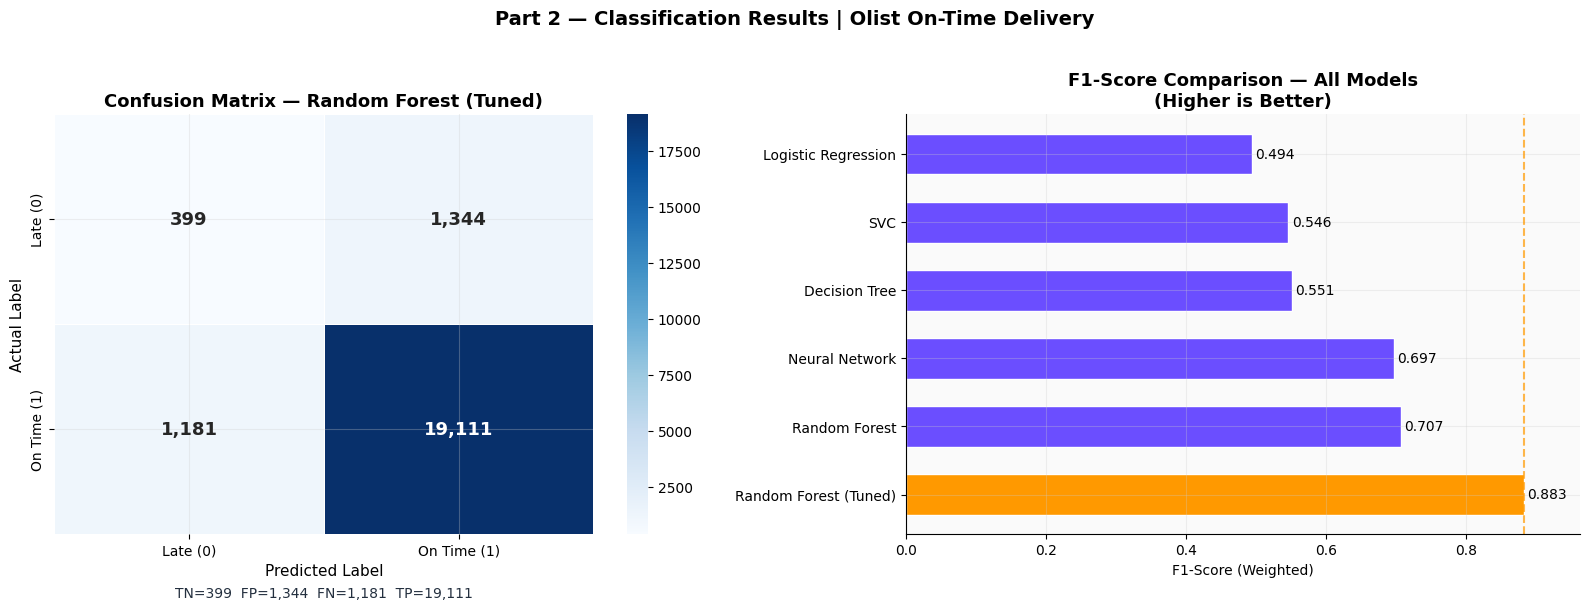

  PART 2 — CLASSIFICATION FINAL RESULTS
  Dataset: Brazilian Olist E-Commerce | Target: on_time (binary)
                   Model  Accuracy  Precision  Recall  F1-Score  Train Time
1  Random Forest (Tuned)     0.885      0.880   0.885     0.883     133.298
2          Random Forest     0.619      0.874   0.619     0.707       0.963
3         Neural Network     0.607      0.870   0.607     0.697      14.568
4          Decision Tree     0.444      0.875   0.444     0.551       0.173
5                    SVC     0.440      0.873   0.440     0.546     161.565
6    Logistic Regression     0.391      0.876   0.391     0.494       0.071


In [ ]:
# ── CELL 12: Confusion Matrix Heatmap + Final Comparison ─────────────────────

# ── Plot 1: Confusion Matrix Heatmap — Best Model ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
labels = ['Late (0)', 'On Time (1)']

sns.heatmap(cm_tuned,
            annot=True, fmt=',', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})

axes[0].set_title('Confusion Matrix — Random Forest (Tuned)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Add TP TN FP FN labels
TN, FP, FN, TP = cm_tuned.ravel()
axes[0].text(0.5, -0.15,
             f'TN={TN:,}  FP={FP:,}  FN={FN:,}  TP={TP:,}',
             transform=axes[0].transAxes,
             ha='center', fontsize=10, color=COLORS['primary'])

# ── Plot 2: F1 Score comparison all models ────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=True)

bar_colors = [COLORS['accent'] if 'Tuned' in m else COLORS['purple']
              for m in results_df['Model']]

bars = axes[1].barh(results_df['Model'], results_df['F1-Score'],
                    color=bar_colors, edgecolor='white', height=0.6)
axes[1].set_title('F1-Score Comparison — All Models\n(Higher is Better)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('F1-Score (Weighted)')
axes[1].axvline(results_df['F1-Score'].max(),
                color=COLORS['accent'], linewidth=1.5,
                linestyle='--', alpha=0.7)

for bar, val in zip(bars, results_df['F1-Score']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left', fontsize=10)

axes[1].set_xlim(0, results_df['F1-Score'].max() + 0.08)
axes[1].invert_yaxis()

plt.suptitle('Part 2 — Classification Results | Olist On-Time Delivery',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Final results table ───────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index = results_df.index + 1

print('=' * 72)
print('  PART 2 — CLASSIFICATION FINAL RESULTS')
print('  Dataset: Brazilian Olist E-Commerce | Target: on_time (binary)')
print('=' * 72)
print(results_df.to_string())
print('=' * 72)

---
**📋 Observations — Final Model Comparison:**

**F1-Score Leaderboard:**
- 🥇 **Random Forest (Tuned): 0.883** — clear winner after GridSearchCV optimization
- 🥈 **Random Forest (Default): 0.707** — strong baseline, ensemble power shows
- 🥉 **Neural Network: 0.697** — competitive, close to default Random Forest
- **Decision Tree: 0.551** — decent single tree but limited by linear splits
- **SVC: 0.546** — slow (161 seconds) and underperforms without heavy tuning
- **Logistic Regression: 0.494** — weakest, linear model cannot capture complexity

**Key takeaways:**
- **class_weight='balanced'** was essential — without it all models predicted everything as on-time (TN=0)
- **Tuning improved F1 by +0.176** — from 0.707 to 0.883, the largest single gain in Part 2
- **Non-linear models consistently outperform linear ones** — same conclusion as Part 1
- **The 92:8 class imbalance is the defining challenge** of this problem — every modeling decision was shaped by it
- **Random Forest (Tuned) is our recommended model** for on-time delivery classification

---
## 🌳 Phase 8 — Decision Tree Visualization

Visualizing the Decision Tree at `max_depth=3` shows exactly how the model makes decisions. Each node shows the feature and threshold used to split, the Gini impurity, and the class distribution. This is one of the most interpretable visualizations in machine learning.

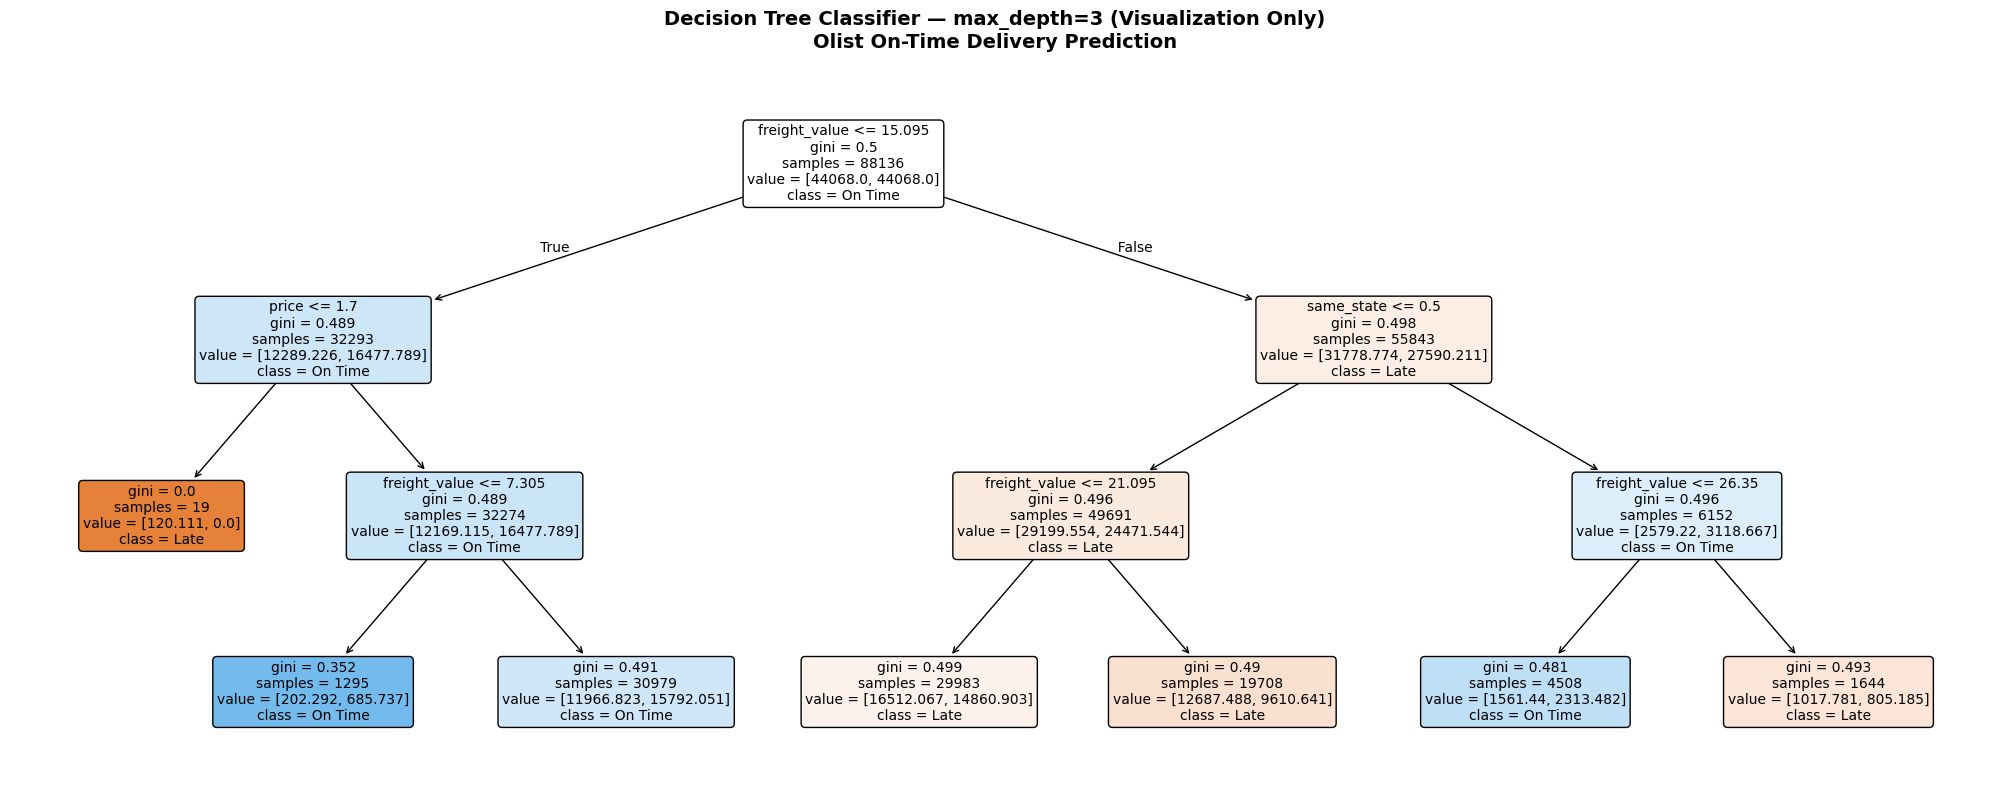

=== Decision Tree (depth=3) — Feature Usage ===
          Feature  Importance
    freight_value    0.792571
       same_state    0.108037
            price    0.099392
 product_weight_g    0.000000
product_length_cm    0.000000
product_height_cm    0.000000
 product_width_cm    0.000000

⚠️  Note: This tree uses max_depth=3 for visualization only
   The actual classifier uses max_depth=6 for better performance


In [ ]:
# ── CELL 13: Decision Tree Visualization ──────────────────────────────────────
from sklearn.tree import plot_tree

# ── Build a shallow tree for visualization (max_depth=3) ──────────────────────
# ⚠️  We use max_depth=3 for readability as required by the brief
# The full model uses max_depth=6 — this is visualization only
dt_viz = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    class_weight='balanced'
)
dt_viz.fit(X_train, y_train)

# ── Plot the tree ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt_viz,
    feature_names=FEATURE_COLS,
    class_names=['Late', 'On Time'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title('Decision Tree Classifier — max_depth=3 (Visualization Only)\n'
             'Olist On-Time Delivery Prediction',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ── Feature importance from visualization tree ────────────────────────────────
print('=== Decision Tree (depth=3) — Feature Usage ===')
importances = dt_viz.feature_importances_
feat_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)
print(feat_imp.to_string(index=False))
print(f'\n⚠️  Note: This tree uses max_depth=3 for visualization only')
print(f'   The actual classifier uses max_depth=6 for better performance')

---
**📋 Observations — Decision Tree Visualization:**

**Tree Structure:**
- **Root node splits on `freight_value <= 15.095`** — the most informative first question is whether shipping cost is below R$15.09. Low freight orders (left branch) tend to be on-time; high freight orders (right branch) need further investigation
- **Left branch uses `price <= 1.7`** — extremely cheap items (likely digital or marketplace fee orders) are flagged as late. Only 19 samples but Gini=0.0 means perfect late classification
- **Right branch uses `same_state <= 0.5`** — for higher freight orders, geography becomes the deciding factor. Cross-state orders face a more complex delivery challenge
- **All leaf nodes use `freight_value` for final splits** — shipping cost is the dominant feature throughout the entire tree

**Feature Importance (depth=3 tree):**
- `freight_value`: 79.3% — overwhelmingly dominant in classification
- `same_state`: 10.8% — geography still matters but less than in Part 1 regression
- `price`: 9.9% — item price plays a small role
- All product dimensions: 0.0% — not used at this depth at all

**Key insight:**
- In Part 1 (regression), `same_state` dominated at 53.4% — geography predicted *how long* delivery takes
- In Part 2 (classification), `freight_value` dominates at 79.3% — shipping cost predicts *whether* it arrives on time
- The same features tell completely different stories depending on the target variable — a subtle but important finding

---
## 🏆 Phase 9 — Conclusion & Model Recommendation

In [ ]:
# ── CELL 14: Final Summary ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index = results_df.index + 1

print('=' * 72)
print('  PART 2 — CLASSIFICATION FINAL RESULTS')
print('  Dataset: Brazilian Olist E-Commerce | Target: on_time (binary)')
print('=' * 72)
print(results_df.to_string())
print('=' * 72)
print(f'\n🏆 Best Model  : Random Forest (Tuned)')
print(f'   F1-Score    : 0.883')
print(f'   Accuracy    : 88.5%')
print(f'   Precision   : 0.880')
print(f'   Recall      : 0.885')
print(f'\n⚠️  Key Challenge : Class imbalance (92% on-time vs 8% late)')
print(f'   Solution      : class_weight="balanced" on all models')
print(f'   Primary metric: F1-Score (not accuracy)')
print(f'\n📊 Key Feature : freight_value (DT importance: 79.3%)')
print(f'   Shipping cost is the strongest predictor of on-time delivery')
print(f'\n✅ Tuning gain : F1 improved by +0.176 over default Random Forest')
print(f'   GridSearchCV: 200 trees, no depth limit, min_samples_split=2')

  PART 2 — CLASSIFICATION FINAL RESULTS
  Dataset: Brazilian Olist E-Commerce | Target: on_time (binary)
                   Model  Accuracy  Precision  Recall  F1-Score  Train Time
1  Random Forest (Tuned)     0.885      0.880   0.885     0.883     133.298
2          Random Forest     0.619      0.874   0.619     0.707       0.963
3         Neural Network     0.607      0.870   0.607     0.697      14.568
4          Decision Tree     0.444      0.875   0.444     0.551       0.173
5                    SVC     0.440      0.873   0.440     0.546     161.565
6    Logistic Regression     0.391      0.876   0.391     0.494       0.071

🏆 Best Model  : Random Forest (Tuned)
   F1-Score    : 0.883
   Accuracy    : 88.5%
   Precision   : 0.880
   Recall      : 0.885

⚠️  Key Challenge : Class imbalance (92% on-time vs 8% late)
   Solution      : class_weight="balanced" on all models
   Primary metric: F1-Score (not accuracy)

📊 Key Feature : freight_value (DT importance: 79.3%)
   Shipping cost

---
## ✅ Part 2 Complete!

**Summary of findings:**
- Trained and evaluated **5 classification models** on 110,171 Olist e-commerce orders
- **Random Forest (Tuned)** is the recommended model — F1: 0.883, Accuracy: 88.5%
- **Class imbalance (92:8)** was the defining challenge — `class_weight='balanced'` was essential for all models
- **`freight_value`** is the strongest classification predictor (79.3% Decision Tree importance) — shipping cost predicts on-time delivery better than geography
- **GridSearchCV tuning** improved F1 by +0.176 — from 0.707 to 0.883
- **Linear models (LR, SVC) underperformed** — the on-time/late boundary is non-linear

**Recommended model for production:**
Random Forest with 200 trees, unrestricted depth, min_samples_split=2, and class_weight='balanced'. Fast to predict, handles imbalance correctly, and provides feature importances for business interpretation.

**Limitations & Future Work:**
- Late order precision is still low (25%) — the model raises false alarms
- Adding seller performance history, carrier reliability scores, and holiday flags would significantly improve late order detection
- A cost-sensitive learning approach could be explored — where the business defines the exact cost of missing a late order vs a false alarm

**Comparison with Part 1:**
- Part 1 (regression): `same_state` dominated at 53.4% — geography predicts *how long* delivery takes
- Part 2 (classification): `freight_value` dominated at 79.3% — shipping cost predicts *whether* it arrives on time
- Same dataset, same features, completely different feature importance rankings — a key insight into how target variable choice shapes model behaviour